# Linear classifier (from scratch)

Linear classifier is a simple model that can be used for binary or multi-class classification. It is a linear model that makes predictions by computing a weighted sum of the input features, plus a bias term. The prediction is the class whose score is the highest. This notebook implements training (multiclass SVM loss + gradient descent) from scratch, without using scikit-learn's classifier — see "Linear Classifier with sklearn" for the scikit-learn version.

**Aprendizado Profundo para Reconhecimento Visual** — Ifes Campus Serra
Autor: Thiago M. Paixão

In [ ]:
# If True, test is running on Colab. Otherwise, test is assumed to be offline.
TEST_ON_COLAB = True
FOLDERNAME = 'Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification'  # only used if TEST_ON_COLAB is True

assert not (FOLDERNAME is None and TEST_ON_COLAB), "FOLDERNAME has to be set if TEST_ON_COLAB is True"

if not TEST_ON_COLAB:
    %load_ext autoreload
    %autoreload 2

In [ ]:
# Create dataset directory
import os

if TEST_ON_COLAB:
    # This mounts your Google Drive to the Colab VM.
    from google.colab import drive

    drive.mount('/content/drive')
    os.chdir(f'/content/drive/My Drive/{FOLDERNAME}')

In [ ]:
![ -f utils.py ] || gdown --id 1NUGtNIABwt4PSAkBXPcMtnKPPaZYmxP3 -O utils.py

## Artificial dataset

In [ ]:
import matplotlib.pyplot as plt
from utils import make_classification_dataset, standard_scaler
from sklearn.model_selection import train_test_split

num_classes = 3
num_features = 2
X, y = make_classification_dataset(1000, num_features, num_classes, cluster_std=3) # try to change the cluster_std to see what happens

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardize X (try to comment this out and see what happens)
X_train, mean, std = standard_scaler(X_train)
X_test, _, _ = standard_scaler(X_test, mean, std)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Plot the dataset
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="gray")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

print(f"X_train_min: {X_train.min()}, X_train_max: {X_train.max()}")

print(f"ymin: {y.min()}, ymax: {y.max()}")

In [ ]:
import numpy as np


def multiclass_svm_loss(scores, y, delta=1.0):
    """
    Naive (non-vectorized) implementation of multiclass SVM loss function (aka multiclass hinge loss) w.r.t. scores.

    Inputs:
    - scores: Input data, of shape (N, C) where x[i, j] is the score for the jth class
      for the ith input.
    - y: True labels, of shape (N,) where y[i] is the label for x[i] and
    - delta: Margin parameter (default is 1.0)

    Returns a tuple of:
    - loss: Scalar giving the loss, of shape (1,)
    - grad: Gradient of the loss with respect to scores, of shape (N, C)
    """

    N, C = scores.shape

    # Naive non-vectorized implementation
    loss = 0.0
    grad = np.zeros(scores.shape)

    for i in range(N):
        for j in range(C):
            if j == y[i]:
                continue
            margin = scores[i, j] - scores[i, y[i]] + delta
            if margin > 0:
                loss += margin
                grad[i, j] += 1
                grad[i, y[i]] -= 1

    # Average the loss and gradient over all examples
    loss /= N
    grad /= N

    return loss, grad


def gradient_wrt_weights_and_biases(grad_scores, scores, X):
    """
    Naive (non-vectorized) implementation of gradient of the loss w.r.t. the weights and biases of the linear model.

    Inputs:
    - grad_scores: Gradient of the loss w.r.t. the scores, of shape (N, C)
    - scores: Input data, of shape (N, C) where x[i, j] is the score for the jth class
      for the ith input.
    - x: Input data, of shape (N, D) where x[i] is the ith input.
    """
    N, C = scores.shape
    D = X.shape[1]

    # Naive non-vectorized implementation
    grad_w = np.zeros((D, C))
    grad_b = np.zeros(C)

    for i in range(N):
        for j in range(C):
            if j == y[i]:
                continue
            grad_w[:, j] += X[i] * grad_scores[i, j]
            grad_w[:, y[i]] -= X[i] * grad_scores[i, j]
            grad_b[j] += grad_scores[i, j]
            grad_b[y[i]] -= grad_scores[i, j]

    # Average the gradient over all examples
    grad_w /= N
    grad_b /= N

    return grad_w, grad_b

## Training

In [ ]:
num_epochs = 1000 # try reducing this to 50 or increasing it to 1000
learning_rate = 1e01 # try reducing this to 1e-1 or 1e-2
num_features = X_train.shape[1]
best_loss = float("inf")
best_params = None
loss_history = []
best_loss_history = []
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Training loop
for epoch in range(num_epochs):
    # Compute scores
    scores = X_train @ W + b

    # Compute loss and gradient w.r.t. scores
    loss, grad_scores = multiclass_svm_loss(scores, y_train)

    # Compute gradient w.r.t. weights and biases
    grad_w, grad_b = gradient_wrt_weights_and_biases(grad_scores, scores, X_train)

    # Update weights and biases
    W -= learning_rate * grad_w
    b -= learning_rate * grad_b

    # Store loss history
    loss_history.append(loss)

    # Check for best loss
    if loss < best_loss:
        best_loss = loss
        best_params = (W.copy(), b.copy())
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss:.4f}, Best Loss: {best_loss:.4f}")

Epoch 1/1000, Loss: 2.0303, Best Loss: 2.0303
Epoch 2/1000, Loss: 1.9919, Best Loss: 1.9919
Epoch 3/1000, Loss: 1.9535, Best Loss: 1.9535
Epoch 4/1000, Loss: 1.9152, Best Loss: 1.9152
Epoch 5/1000, Loss: 1.8768, Best Loss: 1.8768
Epoch 6/1000, Loss: 1.8384, Best Loss: 1.8384
Epoch 7/1000, Loss: 1.8001, Best Loss: 1.8001
Epoch 8/1000, Loss: 1.7617, Best Loss: 1.7617
Epoch 9/1000, Loss: 1.7233, Best Loss: 1.7233
Epoch 10/1000, Loss: 1.6850, Best Loss: 1.6850
Epoch 11/1000, Loss: 1.6466, Best Loss: 1.6466
Epoch 12/1000, Loss: 1.6083, Best Loss: 1.6083
Epoch 13/1000, Loss: 1.5699, Best Loss: 1.5699
Epoch 14/1000, Loss: 1.5315, Best Loss: 1.5315
Epoch 15/1000, Loss: 1.4934, Best Loss: 1.4934
Epoch 16/1000, Loss: 1.4561, Best Loss: 1.4561
Epoch 17/1000, Loss: 1.4200, Best Loss: 1.4200
Epoch 18/1000, Loss: 1.3852, Best Loss: 1.3852
Epoch 19/1000, Loss: 1.3530, Best Loss: 1.3530
Epoch 20/1000, Loss: 1.3239, Best Loss: 1.3239
Epoch 21/1000, Loss: 1.2963, Best Loss: 1.2963
Epoch 22/1000, Loss: 1

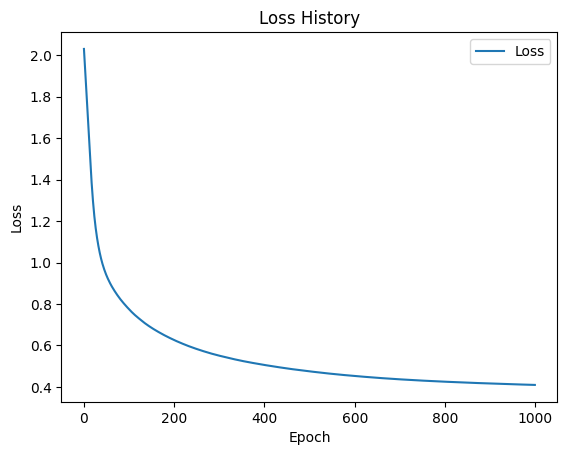

In [ ]:
# Plot loss history
plt.plot(loss_history, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss History")
plt.show()

## Test

In [ ]:
W_best, b_best = best_params
scores = X_test @ W_best + b_best
y_pred = np.argmax(scores, axis=1)

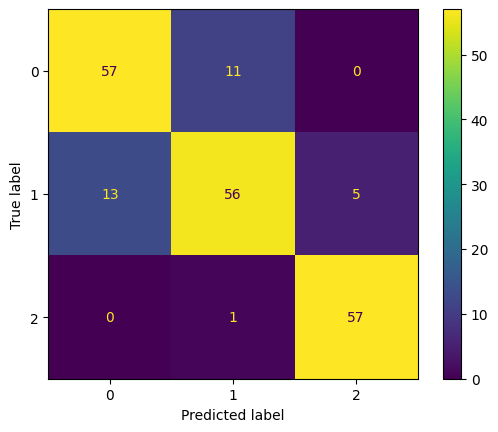


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        68
           1       0.82      0.76      0.79        74
           2       0.92      0.98      0.95        58

    accuracy                           0.85       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.85      0.85      0.85       200



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[class_id for class_id in range(num_classes)])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_id for class_id in range(num_classes)])
disp.plot()
plt.show()

# Compute classification report
class_report = classification_report(y_test, y_pred, target_names=[str(class_id) for class_id in range(num_classes)])

print("\nClassification Report:")
print(class_report)

In [ ]:
print("Predictions:", y_pred)
print("True labels:", y_test)

accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Predictions: [1 1 0 0 0 2 1 2 0 1 0 1 0 1 2 1 0 2 0 0 0 2 1 2 0 2 0 1 2 1 2 0 0 2 2 0 1
 0 0 0 0 0 2 1 0 0 1 0 0 0 0 2 1 2 1 1 1 2 2 2 0 1 1 1 1 0 0 2 1 2 0 1 0 2
 2 0 1 0 0 1 2 1 1 0 0 2 1 1 2 0 1 2 0 1 2 1 1 1 1 2 0 1 1 1 0 0 2 0 0 2 1
 1 1 1 0 1 2 1 2 2 1 2 2 1 1 2 2 0 1 2 2 0 2 2 0 2 1 1 0 0 2 1 2 0 1 2 0 0
 1 0 1 1 1 0 1 0 1 2 2 2 0 1 0 2 1 1 2 2 2 1 0 2 2 2 2 2 0 0 0 1 1 0 0 0 0
 0 2 1 2 2 0 1 2 2 1 1 2 0 0 0]
True labels: [1 1 0 0 0 2 1 2 0 1 1 1 0 0 1 1 0 2 1 0 0 2 1 1 0 2 0 1 2 1 2 0 0 2 2 1 1
 1 0 0 0 0 2 1 1 0 1 0 0 1 1 2 1 2 1 1 0 2 1 2 0 1 1 1 1 0 0 2 1 2 0 1 0 1
 2 0 1 0 1 1 2 0 1 0 0 2 1 0 2 0 1 2 0 1 2 0 1 1 1 2 0 1 1 0 0 0 1 1 0 2 1
 1 1 0 0 1 2 0 2 2 0 2 2 1 1 2 2 0 1 2 2 0 2 2 0 2 1 1 0 0 2 1 2 0 0 2 0 0
 1 1 1 1 1 0 1 0 1 2 2 2 1 1 1 2 1 2 2 2 2 1 1 2 2 2 2 2 0 0 0 0 1 0 0 0 0
 0 2 1 2 2 0 1 2 2 1 1 2 0 0 0]
Accuracy: 0.85
